In [7]:
# @title Elliott Wave Predictor with Fibonacci Projections
# !pip install yfinance pandas numpy matplotlib scipy

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema
from datetime import timedelta

class ElliottWavePredictor:
    def __init__(self, ticker, period='2y', interval='1d'):
        self.ticker = ticker
        print(f"Fetching data for {ticker}...")

        # Download data
        self.data = yf.download(ticker, period=period, interval=interval, progress=False)

        # --- DATA CLEANING (Crucial Fix for yfinance updates) ---
        # 1. If MultiIndex columns (Ticker, Price), drop the Ticker level
        if isinstance(self.data.columns, pd.MultiIndex):
            self.data.columns = self.data.columns.get_level_values(0)

        # 2. Ensure 'Close' is a Series, not a DataFrame
        if isinstance(self.data['Close'], pd.DataFrame):
            self.data['Close'] = self.data['Close'].iloc[:, 0]

        # 3. Drop rows with NaN
        self.data.dropna(inplace=True)

        self.pivots = []
        self.wave_labels = []

    def find_pivots(self, order=5):
        """
        Finds local Highs and Lows.
        """
        df = self.data
        close_vals = df['Close'].values
        dates = df.index

        # Find indexes of local max and min
        # order=5 means it compares to 5 neighbors on each side
        high_idx = argrelextrema(close_vals, np.greater, order=order)[0]
        low_idx = argrelextrema(close_vals, np.less, order=order)[0]

        pivots = []
        for i in high_idx:
            pivots.append((dates[i], float(close_vals[i]), 'High'))
        for i in low_idx:
            pivots.append((dates[i], float(close_vals[i]), 'Low'))

        # Sort by date
        pivots.sort(key=lambda x: x[0])

        # Filter: Ensure alternating Highs and Lows
        clean_pivots = []
        if pivots:
            clean_pivots.append(pivots[0])
            for i in range(1, len(pivots)):
                curr_p = pivots[i]
                prev_p = clean_pivots[-1]

                if curr_p[2] != prev_p[2]:
                    clean_pivots.append(curr_p)
                else:
                    # Update if we found a "higher High" or "lower Low" in the same sequence
                    if curr_p[2] == 'High' and curr_p[1] > prev_p[1]:
                        clean_pivots[-1] = curr_p
                    elif curr_p[2] == 'Low' and curr_p[1] < prev_p[1]:
                        clean_pivots[-1] = curr_p

        self.pivots = clean_pivots
        return clean_pivots

    def label_waves(self):
        """
        Heuristic logic to apply labels (1-5 or A-C) to the most recent pivots.
        """
        if len(self.pivots) < 6:
            return

        # Look at last 6 pivots
        recent = self.pivots[-6:]

        # Logic for Bullish Impulse (Low -> High -> Higher Low -> Higher High)
        # 0=Start, 1=W1, 2=W2, 3=W3, 4=W4, 5=W5

        # Check Impulse Rules
        # 1. Start is Low
        # 2. W2 (idx 2) > Start (idx 0)
        # 3. W3 (idx 3) > W1 (idx 1)
        # 4. W4 (idx 4) > W1 (idx 1) [No Overlap]

        is_impulse = True
        if recent[0][2] != 'Low': is_impulse = False
        if recent[2][1] <= recent[0][1]: is_impulse = False # W2 retrace > 100%
        if recent[4][1] <= recent[1][1]: is_impulse = False # Overlap

        labels = []
        if is_impulse:
            wave_names = ['(0)', '(1)', '(2)', '(3)', '(4)', '(5)']
            for i, p in enumerate(recent):
                labels.append((p[0], p[1], wave_names[i]))
        else:
            # Fallback: Check for Corrective ABC (last 4 points)
            # High -> Low (A) -> Lower High (B) -> Lowest Low (C)
            # OR Low -> High (A) -> Higher Low (B) -> Highest High (C) [ZigZag]
            last_4 = self.pivots[-4:]
            labels = [(last_4[0][0], last_4[0][1], '(0)')]
            labels.append((last_4[1][0], last_4[1][1], 'A'))
            labels.append((last_4[2][0], last_4[2][1], 'B'))
            labels.append((last_4[3][0], last_4[3][1], 'C'))

        self.wave_labels = labels

    def calculate_projections(self):
        """
        Calculates price targets based on the LAST completed swing.
        """
        if len(self.pivots) < 2:
            return None

        # Get last leg
        p_curr = self.pivots[-1] # (Date, Price, Type)
        p_prev = self.pivots[-2]

        price_curr = p_curr[1]
        price_prev = p_prev[1]

        diff = abs(price_curr - price_prev)
        trend = "UP" if price_curr > price_prev else "DOWN"

        projections = {
            'trend': trend,
            'current_price': price_curr,
            'levels': []
        }

        # Fibonacci Ratios
        fib_retrace_shallow = 0.382
        fib_retrace_deep = 0.618
        fib_ext_common = 1.618

        if trend == "UP":
            # Scenario: We just finished a wave UP. Expect a Pullback (Correction).
            # Supports (Retracements)
            s1 = price_curr - (diff * fib_retrace_shallow)
            s2 = price_curr - (diff * 0.5)
            s3 = price_curr - (diff * fib_retrace_deep)

            projections['levels'].append(('Support (0.382)', s1, 'green'))
            projections['levels'].append(('Support (0.500)', s2, 'orange'))
            projections['levels'].append(('Support (0.618)', s3, 'red'))

            # Scenario: Continuation (Extension)
            res = price_prev + (diff * fib_ext_common)
            projections['levels'].append(('Extension (1.618)', res, 'blue'))

        else: # Trend DOWN
            # Scenario: We just finished a wave DOWN. Expect a Bounce.
            # Resistances (Retracements)
            r1 = price_curr + (diff * fib_retrace_shallow)
            r2 = price_curr + (diff * fib_retrace_deep)

            projections['levels'].append(('Resistance (0.382)', r1, 'orange'))
            projections['levels'].append(('Resistance (0.618)', r2, 'red'))

            # Scenario: Continuation Down
            supp = price_prev - (diff * fib_ext_common)
            projections['levels'].append(('Extension Down (1.618)', supp, 'blue'))

        return projections

    def plot_analysis(self):
        plt.figure(figsize=(16, 8))

        # 1. Plot Price
        plt.plot(self.data.index, self.data['Close'], color='black', alpha=0.6, linewidth=1, label='Price')

        # 2. Plot Pivots
        pivot_dates = [p[0] for p in self.pivots]
        pivot_prices = [p[1] for p in self.pivots]
        plt.scatter(pivot_dates, pivot_prices, color='blue', s=30, zorder=5, label='Pivots')
        plt.plot(pivot_dates, pivot_prices, color='blue', alpha=0.3, linestyle='--', linewidth=1)

        # 3. Plot Wave Labels
        for date, price, label in self.wave_labels:
            # Determine offset based on High vs Low for better visibility
            is_high = False
            for p in self.pivots:
                if p[0] == date and p[2] == 'High': is_high = True

            offset = (self.data['Close'].max() - self.data['Close'].min()) * 0.03
            xy_text = (date, price + offset) if is_high else (date, price - offset)
            va = 'bottom' if is_high else 'top'

            plt.annotate(label, (date, price), xytext=xy_text, ha='center', va=va,
                         fontsize=12, fontweight='bold', color='darkblue',
                         arrowprops=dict(arrowstyle='-', color='gray'))

        # 4. Plot Projections (The Forward Looking Part)
        proj = self.calculate_projections()
        if proj:
            last_date = self.data.index[-1]
            future_date = last_date + timedelta(days=45) # Project 45 days out

            # Draw lines
            for name, level, color in proj['levels']:
                plt.hlines(level, xmin=last_date, xmax=future_date, colors=color, linestyles='dashed')
                plt.text(future_date, level, f" {name}: {level:.0f}", verticalalignment='center', color=color, fontsize=9)

            # Add Info Box
            trend_msg = f"Last Move: {proj['trend']}"
            plt.title(f"Elliott Wave Analysis & Projection: {self.ticker} | {trend_msg}", fontsize=14)

        plt.grid(True, which='both', linestyle='--', alpha=0.3)
        plt.legend(loc='upper left')
        plt.show()

        # Text Output
        print(f"\nAnalysis for {self.ticker}:")
        if proj:
            print(f"Current Price: {proj['current_price']:.2f}")
            print(f"Immediate Trend: {proj['trend']}")
            print("\n--- PROJECTED LEVELS (Fibonacci) ---")
            for name, level, _ in proj['levels']:
                print(f"{name:<20}: {level:.2f}")

Fetching data for LPPF.JK...


/tmp/ipython-input-264433976.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.data = yf.download(ticker, period=period, interval=interval, progress=False)


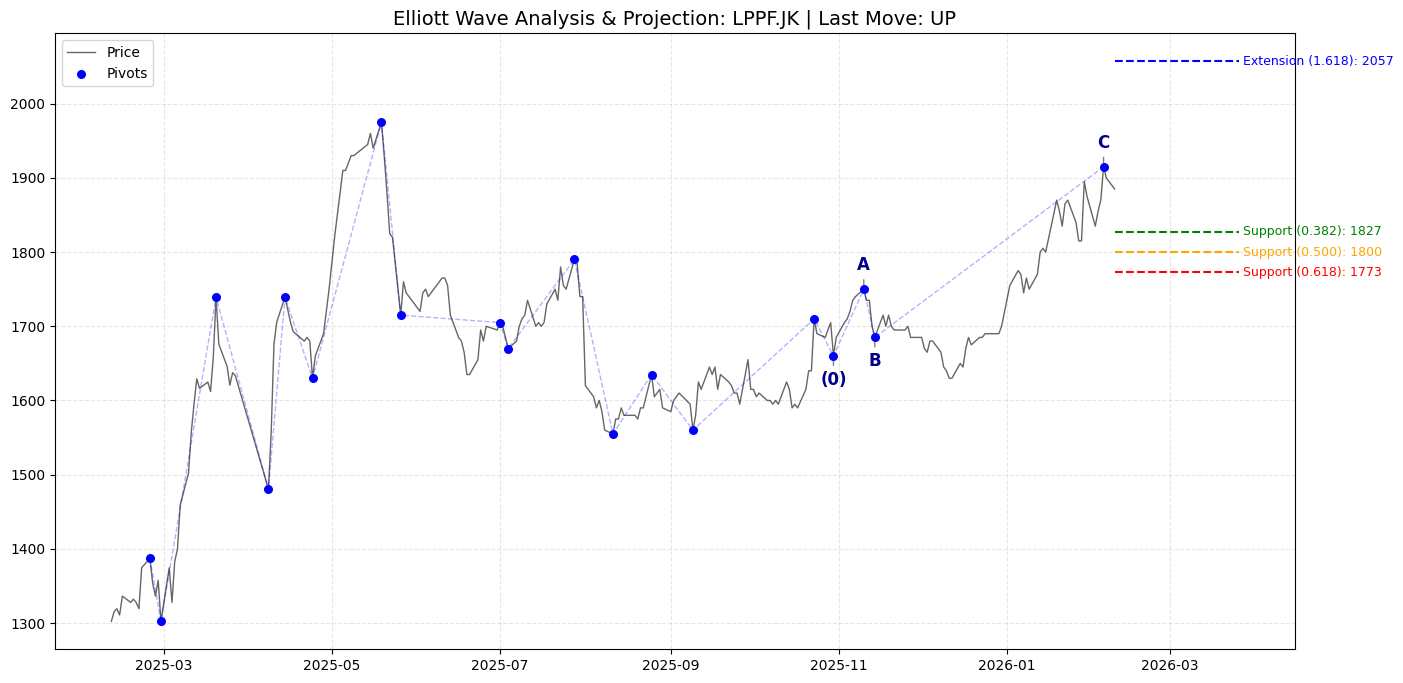


Analysis for LPPF.JK:
Current Price: 1915.00
Immediate Trend: UP

--- PROJECTED LEVELS (Fibonacci) ---
Support (0.382)     : 1827.14
Support (0.500)     : 1800.00
Support (0.618)     : 1772.86
Extension (1.618)   : 2057.14


In [12]:
# --- EXECUTION ---
# Example: TAPG.JK (Triputra Agro Persada)
# Change ticker to any IHSG stock (e.g., BBCA.JK, TLKM.JK, ^JKSE)
analyzer = ElliottWavePredictor('LPPF.JK', period='1y')
analyzer.find_pivots(order=5) # Order=5 filters for significant swings
analyzer.label_waves()
analyzer.plot_analysis()